In [1]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

Kaiming Uniform initialization, SGD with learning rate = 0.001, momentum=0.9

In [2]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*8
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
# hidd_list = [128, 256, 512, 1024, 2048]
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [3]:
eval_list = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

In [4]:
hidden_dim = [hidd_list[0]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.01, use_init="he")
eval_list[0] = evals
losses_list[0] = losses
test_points_list[0] = test_points
weights_list[0] = weights
norms_list[0] = norms

on iteration 0  of k= 10
loss= tensor(8.6666e-05, grad_fn=<MseLossBackward0>)
tensor([0.9705, 0.1231, 0.0708], grad_fn=<SelectBackward0>) tensor([0.9716, 0.1152, 0.0744])
tensor(2.5466e-05, grad_fn=<MseLossBackward0>)
loss= tensor(0.0001, grad_fn=<MseLossBackward0>)
tensor([ 0.1844, -0.1352,  0.0631], grad_fn=<SelectBackward0>) tensor([ 0.1764, -0.1243,  0.0631])
tensor(6.0756e-05, grad_fn=<MseLossBackward0>)
loss= tensor(8.6377e-05, grad_fn=<MseLossBackward0>)
tensor([-0.0760,  0.0077, -0.0098], grad_fn=<SelectBackward0>) tensor([-0.0773,  0.0090, -0.0183])
tensor(2.5372e-05, grad_fn=<MseLossBackward0>)
loss= tensor(7.6201e-05, grad_fn=<MseLossBackward0>)
tensor([-0.1016, -0.0231,  1.0523], grad_fn=<SelectBackward0>) tensor([-0.1005, -0.0283,  1.0515])
tensor(9.6530e-06, grad_fn=<MseLossBackward0>)
loss= tensor(9.0820e-05, grad_fn=<MseLossBackward0>)
tensor([ 0.9551,  0.0449, -0.0171], grad_fn=<SelectBackward0>) tensor([ 0.9557,  0.0449, -0.0195])
tensor(2.0117e-06, grad_fn=<MseLossBa

In [25]:
hidden_dim = [hidd_list[1]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.01, use_init="he")
eval_list[1] = evals
losses_list[1] = losses
test_points_list[1] = test_points
weights_list[1] = weights
norms_list[1] = norms

on iteration 0  of k= 10
loss= tensor(0.0002, grad_fn=<MseLossBackward0>)
tensor([ 0.9267, -0.0497, -0.0504], grad_fn=<SelectBackward0>) tensor([ 0.9250, -0.0522, -0.0431])
tensor(2.1129e-05, grad_fn=<MseLossBackward0>)
loss= tensor(4.2539e-05, grad_fn=<MseLossBackward0>)
tensor([ 0.1337, -0.1709,  0.0235], grad_fn=<SelectBackward0>) tensor([ 0.1380, -0.1671,  0.0151])
tensor(3.4748e-05, grad_fn=<MseLossBackward0>)
loss= tensor(0.0020, grad_fn=<MseLossBackward0>)
tensor([0.0055, 0.0226, 0.9635], grad_fn=<SelectBackward0>) tensor([0.0054, 0.0240, 0.9610])
tensor(2.7716e-06, grad_fn=<MseLossBackward0>)
loss= tensor(8.8352e-05, grad_fn=<MseLossBackward0>)
tensor([0.0312, 0.9078, 0.0188], grad_fn=<SelectBackward0>) tensor([0.0300, 0.9036, 0.0218])
tensor(9.1638e-06, grad_fn=<MseLossBackward0>)
loss= tensor(0.0001, grad_fn=<MseLossBackward0>)
tensor([-0.0713,  1.0575,  0.1739], grad_fn=<SelectBackward0>) tensor([-0.0673,  1.0383,  0.1949])
tensor(0.0003, grad_fn=<MseLossBackward0>)
loss= te

In [26]:
for i in range(k):
    for hd in range(n_hiddDim):
        for layer in range(2):
            torch.save({'linear.weight': weights_list[hd][0][i][2*layer], 'linear.bias': weights_list[hd][0][i][2*layer+1]}, 
                   "dim=%s_layer=" % hidd_list[hd] + str(layer) + "_k="+str(i)+".pth")

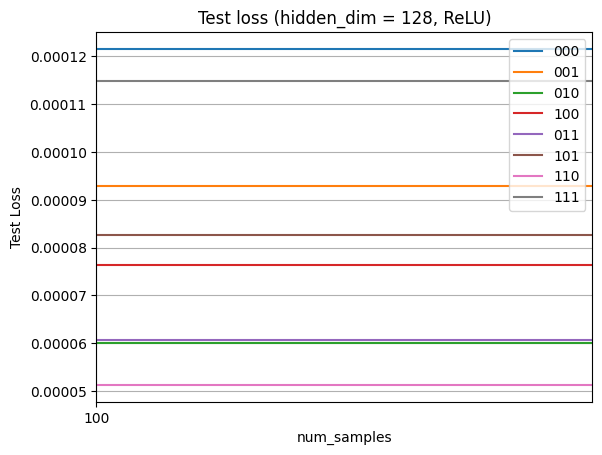

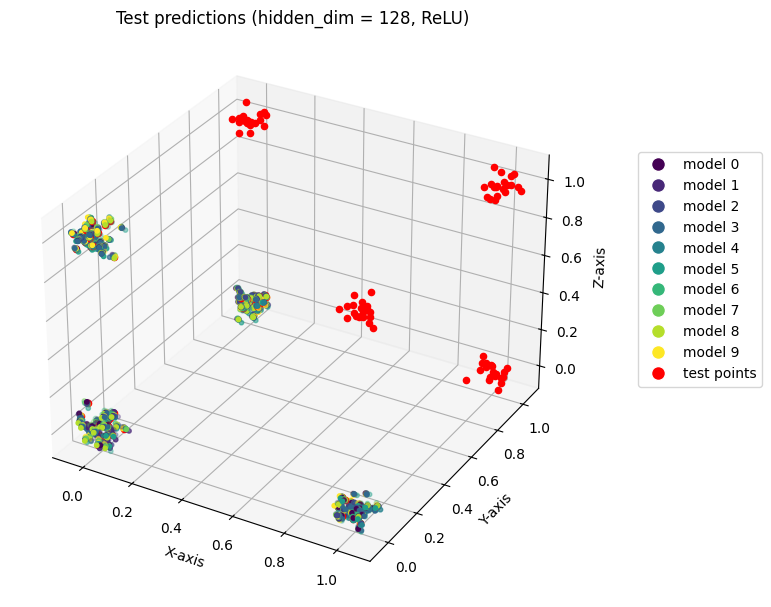

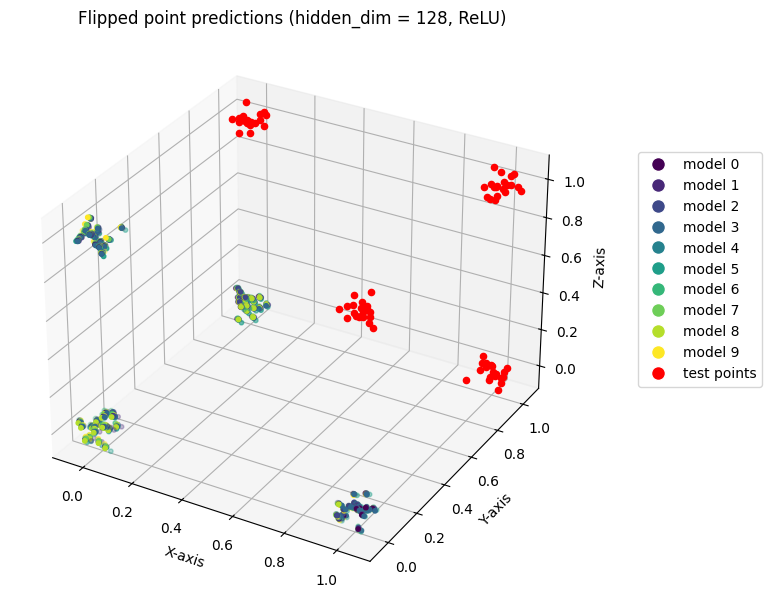

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [27]:
testLoss_list = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss = compute_clusterLoss(eval_list[i], flippedIdentity(test_points_list[i]), test_centers)
    plot_clusterTestLoss(np.hstack((testLoss, testLoss)), test_centers, hidden_dim)
    testLoss_list[i] = np.reshape(testLoss, (8))
    
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(8))
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(4,8), title='Flipped point predictions (hidden_dim = %s, ' % hidden_dim + 'ReLU)')
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=1000)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=1000)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list[i][0][j][-1]))

    plot_norms(norms_list[i], hidden_dim)
    plot_norms(np.mean(norms_list[i], axis=1, keepdims=True), hidden_dim)
    

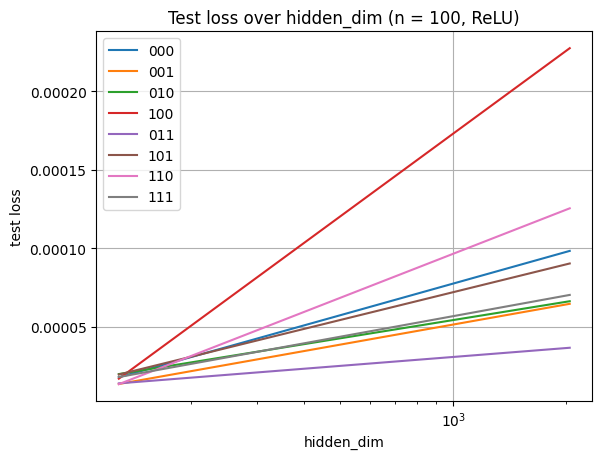

In [ ]:
plot_hiddDim(np.array(testLoss_list), test_centers, hidd_list, lo=100)